In [1]:
import glob

import matplotlib.pyplot as plt
import numpy as np
import sklearn.metrics

n_classes = 5

In [2]:
from os.path import dirname

path_sweep_soft_voting = "../../logs/exp002/exp002a/sweep-2026-09-04_18-37-48_30s-soft-voting"
labels_glob_soft_voting = f"{path_sweep_soft_voting}/*/labels.npz"
preds_glob_soft_voting = f"{path_sweep_soft_voting}/*/predictions.npz"

labels_files_soft_voting = sorted(glob.glob(labels_glob_soft_voting), key=lambda x: int(x.split("/")[-2]))
preds_files_soft_voting = sorted(glob.glob(preds_glob_soft_voting), key=lambda x: int(x.split("/")[-2]))


def calc_f1_from_cm(cm):
    tps = cm.diagonal()
    fps = cm.sum(axis=0) - tps
    fns = cm.sum(axis=1) - tps
    valid = (tps + fps + fns) > 0
    f1s = np.zeros(n_classes)
    f1s[valid] = 2 * tps[valid] / (2 * tps[valid] + fps[valid] + fns[valid])
    return f1s[valid].mean()


mf1s_per_model_ds_sr_soft_voting = {}
for label_file, pred_file in zip(labels_files_soft_voting, preds_files_soft_voting):
    labels_dict = np.load(label_file)
    preds_dict = np.load(pred_file)
    preds_dict = {"_".join(k.split("#")[:2]): v for k, v in preds_dict.items()}

    with open(dirname(label_file) + "/predict-30s-from-high-freq.log") as f:
        lines = f.readlines()
        sr_line = [line for line in lines if "sleep_stage_frequency" in line][0]
        sleep_stage_sr = int(sr_line.split("=")[1])
        model_line = [line for line in lines if "model.path" in line][0]
        model = model_line.split("=")[1].strip()

    subj_mf1s = {}
    for ds_subj_key in sorted(labels_dict.keys()):
        labels = labels_dict[ds_subj_key].flatten()
        preds = preds_dict[ds_subj_key]
        if labels.shape[0] != preds.shape[0]:
            print(ds_subj_key, labels.shape, preds.shape[0])
            continue

        cm = sklearn.metrics.confusion_matrix(labels, preds, labels=np.arange(n_classes))
        subj_mf1s.setdefault(ds_subj_key.split("_")[0], {})[ds_subj_key] = calc_f1_from_cm(cm)

    for ds, subj_dict in sorted(subj_mf1s.items()):
        mf1s = np.array(list(subj_dict.values()))
        print(f"{model}, {ds}, {sleep_stage_sr} pred/epoch, avg. MF1: {mf1s.mean():.2f} +/- {mf1s.std():.2f}")
        if ds not in mf1s_per_model_ds_sr_soft_voting:
            mf1s_per_model_ds_sr_soft_voting[ds] = {}
        if model not in mf1s_per_model_ds_sr_soft_voting[ds]:
            mf1s_per_model_ds_sr_soft_voting[ds][model] = {}
        mf1s_per_model_ds_sr_soft_voting[ds][model][sleep_stage_sr] = subj_dict

anysleep-run1.pth, dodh, 1 pred/epoch, avg. MF1: 0.80 +/- 0.07
anysleep-run1.pth, dodo, 1 pred/epoch, avg. MF1: 0.76 +/- 0.09
anysleep-run1.pth, isruc-sg1, 1 pred/epoch, avg. MF1: 0.75 +/- 0.06
anysleep-run1.pth, isruc-sg2, 1 pred/epoch, avg. MF1: 0.71 +/- 0.12
anysleep-run1.pth, isruc-sg3, 1 pred/epoch, avg. MF1: 0.74 +/- 0.04
anysleep-run1.pth, mass-c1, 1 pred/epoch, avg. MF1: 0.69 +/- 0.07
anysleep-run1.pth, mass-c3, 1 pred/epoch, avg. MF1: 0.77 +/- 0.07
anysleep-run1.pth, svuh, 1 pred/epoch, avg. MF1: 0.70 +/- 0.10
anysleep-run1.pth, dodh, 4 pred/epoch, avg. MF1: 0.80 +/- 0.07
anysleep-run1.pth, dodo, 4 pred/epoch, avg. MF1: 0.76 +/- 0.09
anysleep-run1.pth, isruc-sg1, 4 pred/epoch, avg. MF1: 0.75 +/- 0.06
anysleep-run1.pth, isruc-sg2, 4 pred/epoch, avg. MF1: 0.71 +/- 0.12
anysleep-run1.pth, isruc-sg3, 4 pred/epoch, avg. MF1: 0.74 +/- 0.04
anysleep-run1.pth, mass-c1, 4 pred/epoch, avg. MF1: 0.69 +/- 0.07
anysleep-run1.pth, mass-c3, 4 pred/epoch, avg. MF1: 0.77 +/- 0.07
anysleep-run1

In [3]:
from os.path import dirname

path_sweep_hard_voting = "../../logs/exp002/exp002a/sweep-2026-09-04_18-37-55_30s-hard-voting"
labels_glob_hard_voting = f"{path_sweep_hard_voting}/*/labels.npz"
preds_glob_hard_voting = f"{path_sweep_hard_voting}/*/predictions.npz"

labels_files_hard_voting = sorted(glob.glob(labels_glob_hard_voting), key=lambda x: int(x.split("/")[-2]))
preds_files_hard_voting = sorted(glob.glob(preds_glob_hard_voting), key=lambda x: int(x.split("/")[-2]))

mf1s_per_model_ds_sr_hard_voting = {}
for label_file, pred_file in zip(labels_files_hard_voting, preds_files_hard_voting):
    labels_dict = np.load(label_file)
    preds_dict = np.load(pred_file)
    preds_dict = {"_".join(k.split("#")[:2]): v for k, v in preds_dict.items()}

    with open(dirname(label_file) + "/predict-30s-from-high-freq.log") as f:
        lines = f.readlines()
        sr_line = [line for line in lines if "sleep_stage_frequency" in line][0]
        sleep_stage_sr = int(sr_line.split("=")[1])
        model_line = [line for line in lines if "model.path" in line][0]
        model = model_line.split("=")[1].strip()

    subj_mf1s = {}
    for ds_subj_key in sorted(labels_dict.keys()):
        labels = labels_dict[ds_subj_key].flatten()
        preds = preds_dict[ds_subj_key]
        if labels.shape[0] != preds.shape[0]:
            print(ds_subj_key, labels.shape, preds.shape[0])
            continue

        cm = sklearn.metrics.confusion_matrix(labels, preds, labels=np.arange(n_classes))
        subj_mf1s.setdefault(ds_subj_key.split("_")[0], {})[ds_subj_key] = calc_f1_from_cm(cm)

    for ds, subj_dict in sorted(subj_mf1s.items()):
        mf1s = np.array(list(subj_dict.values()))
        print(f"{model}, {ds}, {sleep_stage_sr} pred/epoch, avg. MF1: {mf1s.mean():.2f} +/- {mf1s.std():.2f}")
        if ds not in mf1s_per_model_ds_sr_hard_voting:
            mf1s_per_model_ds_sr_hard_voting[ds] = {}
        if model not in mf1s_per_model_ds_sr_hard_voting[ds]:
            mf1s_per_model_ds_sr_hard_voting[ds][model] = {}
        mf1s_per_model_ds_sr_hard_voting[ds][model][sleep_stage_sr] = subj_dict

anysleep-run1.pth, dodh, 1 pred/epoch, avg. MF1: 0.80 +/- 0.07
anysleep-run1.pth, dodo, 1 pred/epoch, avg. MF1: 0.76 +/- 0.09
anysleep-run1.pth, isruc-sg1, 1 pred/epoch, avg. MF1: 0.75 +/- 0.06
anysleep-run1.pth, isruc-sg2, 1 pred/epoch, avg. MF1: 0.71 +/- 0.12
anysleep-run1.pth, isruc-sg3, 1 pred/epoch, avg. MF1: 0.74 +/- 0.04
anysleep-run1.pth, mass-c1, 1 pred/epoch, avg. MF1: 0.69 +/- 0.07
anysleep-run1.pth, mass-c3, 1 pred/epoch, avg. MF1: 0.77 +/- 0.07
anysleep-run1.pth, svuh, 1 pred/epoch, avg. MF1: 0.70 +/- 0.10
anysleep-run1.pth, dodh, 4 pred/epoch, avg. MF1: 0.79 +/- 0.06
anysleep-run1.pth, dodo, 4 pred/epoch, avg. MF1: 0.76 +/- 0.09
anysleep-run1.pth, isruc-sg1, 4 pred/epoch, avg. MF1: 0.74 +/- 0.06
anysleep-run1.pth, isruc-sg2, 4 pred/epoch, avg. MF1: 0.70 +/- 0.12
anysleep-run1.pth, isruc-sg3, 4 pred/epoch, avg. MF1: 0.73 +/- 0.03
anysleep-run1.pth, mass-c1, 4 pred/epoch, avg. MF1: 0.69 +/- 0.07
anysleep-run1.pth, mass-c3, 4 pred/epoch, avg. MF1: 0.76 +/- 0.07
anysleep-run1

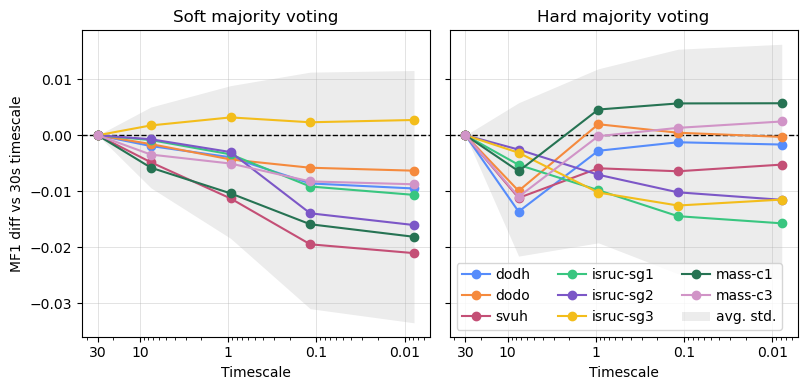

In [4]:
import matplotlib

base_sr = 1  # 30s epoch (1 pred/epoch)
ds_order = ["dodh", "dodo", "svuh", "isruc-sg1", "isruc-sg2", "isruc-sg3", "mass-c1", "mass-c3"]
_, axes = plt.subplots(1, 2, sharey=True, figsize=(8.5, 4))
axes = axes.flatten()

for axis, score_dict in zip(axes, [mf1s_per_model_ds_sr_soft_voting, mf1s_per_model_ds_sr_hard_voting]):
    all_stds, all_means = [], []
    axis.axhline(0, color="black", linewidth=1, linestyle="--")

    for ds in ds_order:
        srs = sorted(set.intersection(*[set(score_dict[ds][model].keys())
                                        for model in score_dict[ds]]))
        subj_keys = sorted(set().union(*[set(score_dict[ds][model][sr])
                                         for model in score_dict[ds]
                                         for sr in srs]))
        diffs = np.array([[[score_dict[ds][model][sr][subj] - score_dict[ds][model][base_sr][subj]
                            for subj in subj_keys]
                           for sr in srs]
                          for model in score_dict[ds]])
        srs_axis = np.array([30 / s for s in srs])
        axis.plot(srs_axis, diffs.mean(axis=(0, 2)), label=ds, marker="o", linestyle="-")
        all_stds.append(diffs.std(axis=(0, 2)))
        all_means.append(diffs.mean(axis=(0, 2)))

    agg_std = np.mean(all_stds, axis=0)
    grand_mean = np.mean(all_means, axis=0)
    axis.fill_between(srs_axis,
                      grand_mean - agg_std,
                      grand_mean + agg_std,
                      color="gray", alpha=0.15, linewidth=0,
                      label="avg. std.")

    axis.semilogx()
    ticks = [10 ** k for k in range(-5, 2) if
             min(srs_axis) <= 10 ** k <= max(srs_axis)]
    if min(srs_axis) <= 30 <= max(srs_axis):
        ticks.append(30)
    ticks = sorted(ticks, reverse=True)
    axis.set_xticks(ticks, [f"{t:g}" for t in ticks])
    axis.xaxis.set_minor_formatter(matplotlib.ticker.NullFormatter())
    axis.grid(axis="both")
    axis.set_xlabel("Timescale")
    axis.invert_xaxis()
axes[0].set_title("Soft majority voting")
axes[1].set_title("Hard majority voting")
axes[1].legend(ncol=3,
               handletextpad=0.4)
axes[0].set_ylabel("MF1 diff vs 30s timescale")
plt.tight_layout()
plt.savefig("fig_s5.svg")
plt.show()